In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
data = {
    "day": [1, 2, 3, 4, 5],
    "pnl": [0, 200, -100, 700, 180]
}

df = pd.DataFrame(data)
df


,day,pnl
0,1,0
1,2,200
2,3,-100
3,4,700
4,5,180


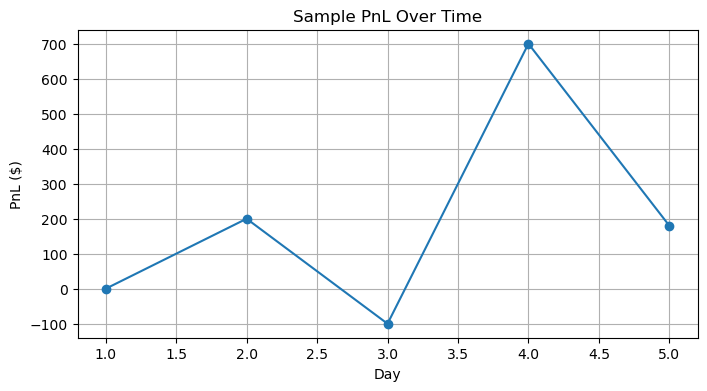

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(df["day"], df["pnl"], marker="o")
plt.title("Sample PnL Over Time")
plt.xlabel("Day")
plt.ylabel("PnL ($)")
plt.grid(True)
plt.show()


In [18]:
import pandas as pd

df = pd.read_csv("data/sample_pnl.csv")
df


,day,pnl
0,1,0
1,2,200
2,3,-100
3,4,-400
4,5,180


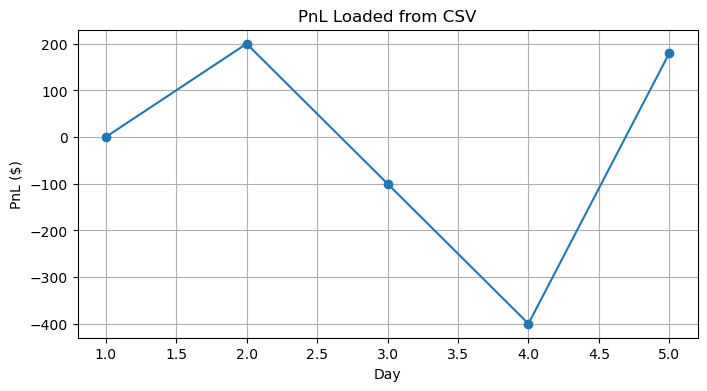

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df["day"], df["pnl"], marker="o")
plt.title("PnL Loaded from CSV")
plt.xlabel("Day")
plt.ylabel("PnL ($)")
plt.grid(True)
plt.show()


In [12]:
import os
os.getcwd()


'C:\\Users\\phemm\\orb_lab'

In [20]:
df["equity"] = df["pnl"].cumsum()
df


,day,pnl,equity
0,1,0,0
1,2,200,200
2,3,-100,100
3,4,-400,-300
4,5,180,-120


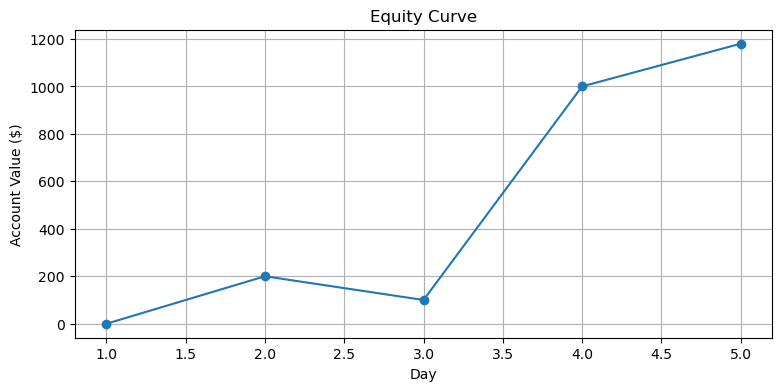

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(df["day"], df["equity"], marker="o")
plt.title("Equity Curve")
plt.xlabel("Day")
plt.ylabel("Account Value ($)")
plt.grid(True)
plt.show()


In [21]:
df["peak"] = df["equity"].cummax()
df["drawdown"] = df["equity"] - df["peak"]
df


,day,pnl,equity,peak,drawdown
0,1,0,0,0,0
1,2,200,200,200,0
2,3,-100,100,200,-100
3,4,-400,-300,200,-500
4,5,180,-120,200,-320


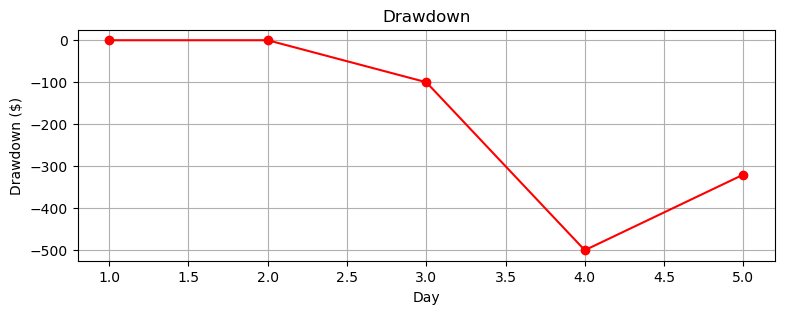

In [22]:
plt.figure(figsize=(9, 3))
plt.plot(df["day"], df["drawdown"], color="red", marker="o")
plt.title("Drawdown")
plt.xlabel("Day")
plt.ylabel("Drawdown ($)")
plt.grid(True)
plt.show()


In [23]:
import pandas as pd

df_1m = pd.read_csv("data/sample_pnl.csv")
df_2m = pd.read_csv("data/sample_pnl_2min.csv")

df_1m, df_2m


(   day  pnl
 0    1    0
 1    2  200
 2    3 -100
 3    4 -400
 4    5  180,
    day  pnl
 0    1    0
 1    2  150
 2    3   50
 3    4  500
 4    5  300)

In [24]:
df_1m["equity"] = df_1m["pnl"].cumsum()
df_2m["equity"] = df_2m["pnl"].cumsum()


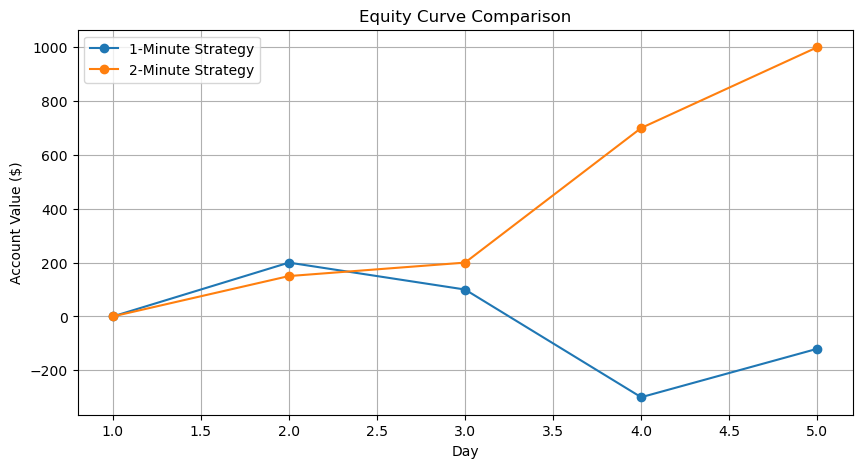

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(df_1m["day"], df_1m["equity"], marker="o", label="1-Minute Strategy")
plt.plot(df_2m["day"], df_2m["equity"], marker="o", label="2-Minute Strategy")

plt.title("Equity Curve Comparison")
plt.xlabel("Day")
plt.ylabel("Account Value ($)")
plt.grid(True)
plt.legend()
plt.show()


In [26]:
df_2m


,day,pnl,equity
0,1,0,0
1,2,150,150
2,3,50,200
3,4,500,700
4,5,300,1000


In [27]:
train = df_2m[df_2m["day"] <= 3]
test  = df_2m[df_2m["day"] > 3]

train, test


(   day  pnl  equity
 0    1    0       0
 1    2  150     150
 2    3   50     200,
    day  pnl  equity
 3    4  500     700
 4    5  300    1000)

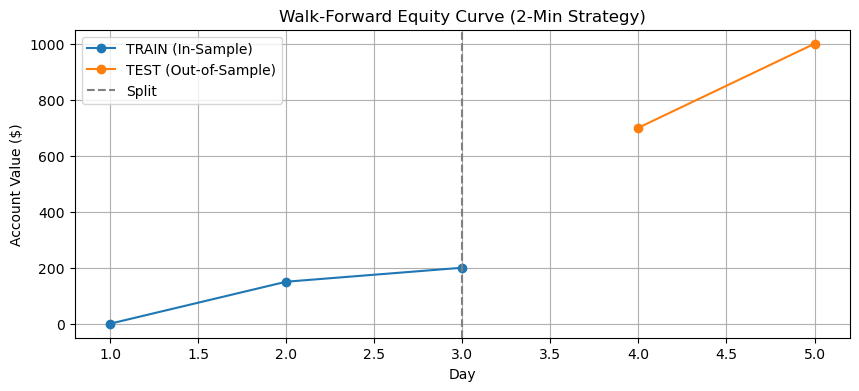

In [28]:
plt.figure(figsize=(10, 4))

plt.plot(train["day"], train["equity"], marker="o", label="TRAIN (In-Sample)")
plt.plot(test["day"], test["equity"], marker="o", label="TEST (Out-of-Sample)")

plt.axvline(x=3, color="gray", linestyle="--", label="Split")

plt.title("Walk-Forward Equity Curve (2-Min Strategy)")
plt.xlabel("Day")
plt.ylabel("Account Value ($)")
plt.grid(True)
plt.legend()
plt.show()


In [36]:
def equity_metrics(df, min_dd=1):
    equity = df["equity"]
    peak = equity.cummax()
    drawdown = equity - peak
    
    final_equity = equity.iloc[-1]
    max_drawdown = drawdown.min()
    
    # Enforce minimum drawdown to avoid infinity
    effective_dd = abs(max_drawdown) if abs(max_drawdown) >= min_dd else min_dd
    
    return {
        "final_equity": final_equity,
        "max_drawdown": max_drawdown,
        "return_to_dd": final_equity / effective_dd
    }


In [37]:
metrics_1m = equity_metrics(df_1m)
metrics_2m = equity_metrics(df_2m)

metrics_1m, metrics_2m


({'final_equity': np.int64(-120),
  'max_drawdown': -500,
  'return_to_dd': np.float64(-0.24)},
 {'final_equity': np.int64(1000),
  'max_drawdown': 0,
  'return_to_dd': np.float64(1000.0)})

In [38]:
import numpy as np

def generate_fake_pnl(seed, days=20):
    np.random.seed(seed)
    # Random daily PnL with slight positive bias
    return np.random.normal(loc=50, scale=200, size=days)


In [39]:
strategies = []

for i in range(20):  # pretend 20 parameter trials
    pnl = generate_fake_pnl(seed=i)
    
    df = pd.DataFrame({
        "day": range(1, len(pnl) + 1),
        "pnl": pnl
    })
    
    df["equity"] = df["pnl"].cumsum()
    
    metrics = equity_metrics(df)
    
    strategies.append({
        "trial": i,
        **metrics,
        "df": df
    })


In [40]:
results = pd.DataFrame([
    {k: v for k, v in s.items() if k != "df"}
    for s in strategies
])

results.sort_values("return_to_dd", ascending=False).head(5)


,trial,final_equity,max_drawdown,return_to_dd
0,0,3277.338372,-145.455576,22.531542
18,18,2544.729175,-319.285641,7.970071
10,10,1474.877916,-259.080058,5.692750
13,13,2465.610580,-469.194420,5.254987
6,6,1945.181268,-577.174490,3.370179


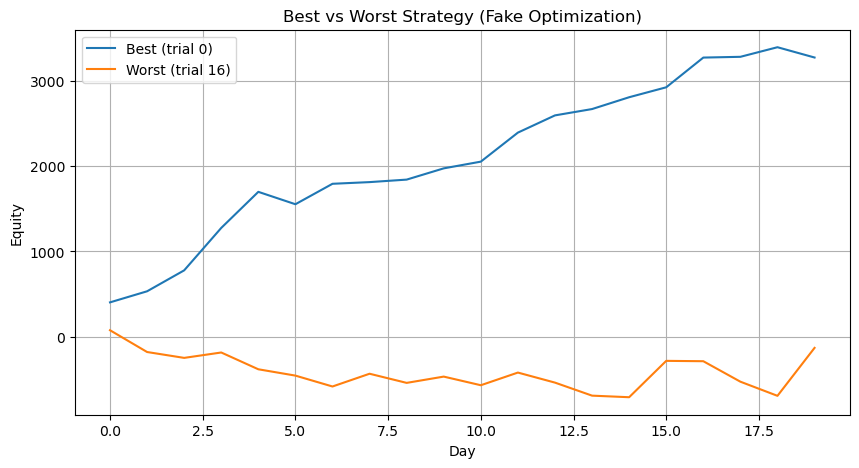

In [41]:
best = max(strategies, key=lambda s: s["return_to_dd"])
worst = min(strategies, key=lambda s: s["return_to_dd"])

plt.figure(figsize=(10, 5))
plt.plot(best["df"]["equity"], label=f"Best (trial {best['trial']})")
plt.plot(worst["df"]["equity"], label=f"Worst (trial {worst['trial']})")
plt.title("Best vs Worst Strategy (Fake Optimization)")
plt.xlabel("Day")
plt.ylabel("Equity")
plt.grid(True)
plt.legend()
plt.show()


In [43]:

# Walk-forward configuration
TOTAL_DAYS = 60
TRAIN_DAYS = 40
TEST_DAYS = TOTAL_DAYS - TRAIN_DAYS

TOTAL_DAYS, TRAIN_DAYS, TEST_DAYS




trials = []

for trial in range(50):  # pretend 50 parameter combos
    pnl = generate_fake_pnl(seed=trial, days=TOTAL_DAYS)

    df = pd.DataFrame({
        "day": range(1, TOTAL_DAYS + 1),
        "pnl": pnl
    })
    df["equity"] = df["pnl"].cumsum()

    train_df = df.iloc[:TRAIN_DAYS].copy()
    test_df  = df.iloc[TRAIN_DAYS:].copy()

    # Rebase TEST equity so it starts at 0 (so we measure TEST performance cleanly)
    test_df["equity"] = test_df["pnl"].cumsum()

    train_metrics = equity_metrics(train_df)
    test_metrics  = equity_metrics(test_df)

    trials.append({
        "trial": trial,
        "train_score": train_metrics["return_to_dd"],
        "test_score": test_metrics["return_to_dd"],
        "train_final": train_metrics["final_equity"],
        "test_final": test_metrics["final_equity"],
        "df_all": df,
        "df_train": train_df,
        "df_test": test_df
    })

len(trials)


50